In [1]:
# Installs the Python packages needed for this notebook in Google Colab, including BigQuery access, data manipulation, machine learning, and visualization libraries.
!pip install -q google-cloud-bigquery pandas scikit-learn matplotlib seaborn


Installs the Python packages needed for this notebook in Google Colab, including BigQuery access, data manipulation, machine learning, and visualization libraries.

In [2]:
# Authenticates the Colab session with Google Cloud, imports the BigQuery client, and stores the project and dataset identifiers that will be used for queries later in the notebook.
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

PROJECT_ID = "big-data-algorithms-493312"
DATASET_ID = "aramark_spend"
client = bigquery.Client(project=PROJECT_ID)

print("Connected to:", PROJECT_ID)

Connected to: big-data-algorithms-493312


Authenticates the Colab session with Google Cloud, imports the BigQuery client, and stores the project and dataset identifiers that will be used for queries later in the notebook.

In [3]:
# Runs a quick validation query against the raw_spend table to confirm that the connection works and to verify the table size before sampling.
test_sql = f"""
SELECT COUNT(*) AS row_count
FROM `{PROJECT_ID}.{DATASET_ID}.raw_spend`
"""
client.query(test_sql).to_dataframe()
# Expected: ~42,967,459 rows

,row_count
0,42967459


Runs a quick validation query against the raw_spend table to confirm that the connection works and to verify the table size before sampling.

In [4]:
# Uses BigQuery TABLESAMPLE to pull an approximate 1 percent preview of the raw spend table, selecting only the columns needed for segmentation and filtering out known bad rows.
# TABLESAMPLE grabs approximately 1% of the table — ~430K rows.
# Adjust the PERCENT value if you want more or fewer rows.
sql = f"""
SELECT
  year_month,
  business_entity_type,
  customer_market_segment_id,
  state,
  city,
  number_of_rooms,
  distributor_group,
  category_level_1,
  category_level_2,
  spend_random_factor
FROM `{PROJECT_ID}.{DATASET_ID}.raw_spend` TABLESAMPLE SYSTEM (1 PERCENT)
WHERE state NOT IN ('GEORGIA', 'AB')   -- drop the known bad rows
"""
df = client.query(sql).to_dataframe()
print("Sample shape:", df.shape)
df.head()

Sample shape: (220491, 10)


,year_month,business_entity_type,customer_market_segment_id,state,city,number_of_rooms,distributor_group,category_level_1,category_level_2,spend_random_factor
0,202504,GPO,MS-100003,CA,FONTANA,0,MASTER DISTRIBUTOR,FOOD,PRODUCE,437.635135
1,202502,GPO,MS-100003,CA,FONTANA,0,MASTER DISTRIBUTOR,FOOD,GROCERY,107.351351
2,202504,GPO,MS-100003,CA,FONTANA,0,MASTER DISTRIBUTOR,FOOD,DAIRY,9398.018018
3,202505,GPO,MS-100003,CA,FONTANA,0,MASTER DISTRIBUTOR,FOOD,BAKERY,359.729730
4,202508,GPO,MS-100003,CA,FONTANA,0,MASTER DISTRIBUTOR,FOOD,POULTRY,59.783784


Uses BigQuery TABLESAMPLE to pull an approximate 1 percent preview of the raw spend table, selecting only the columns needed for segmentation and filtering out known bad rows.

In [5]:
# Draws the main modeling sample with a RAND filter, returning roughly 500K rows into pandas for local preprocessing and clustering.
sql_sample=f"""SELECT * FROM `big-data-algorithms-493312.aramark_spend.raw_spend`
WHERE RAND() < 0.012"""
df_sample = client.query(sql_sample).to_dataframe()
print("Sample shape:", df_sample.shape)


Sample shape: (516010, 23)


Draws the main modeling sample with a RAND filter, returning roughly 500K rows into pandas for local preprocessing and clustering.

In [6]:
# Creates a working copy of the sampled data and fills missing values in the key segmentation fields so the downstream feature engineering and clustering steps do not break on nulls.
import numpy as np
import pandas as pd

seg_df = df_sample.copy()

seg_df["distributor_group"] = seg_df["distributor_group"].fillna("Unknown")
seg_df["category_level_1"] = seg_df["category_level_1"].fillna("Unknown")
seg_df["business_entity_type"] = seg_df["business_entity_type"].fillna("Unknown")
seg_df["number_of_rooms"] = seg_df["number_of_rooms"].fillna(0)

print(seg_df[[
    "distributor_group",
    "category_level_1",
    "business_entity_type",
    "number_of_rooms"
]].isna().sum())

distributor_group       0
category_level_1        0
business_entity_type    0
number_of_rooms         0
dtype: int64


Creates a working copy of the sampled data and fills missing values in the key segmentation fields so the downstream feature engineering and clustering steps do not break on nulls.

In [7]:
# Cleans the spend feature by clipping negative values and then applies a log transform so extreme spend values have less influence during clustering.
seg_df["spend_random_factor"] = seg_df["spend_random_factor"].clip(lower=0)
seg_df["log_spend_random_factor"] = np.log1p(seg_df["spend_random_factor"])

seg_df[["spend_random_factor", "log_spend_random_factor"]].head()


,spend_random_factor,log_spend_random_factor
0,9.292793,2.331444
1,33.490991,3.540698
2,28.950450,3.399544
3,24.738739,3.247997
4,36.441441,3.622778


Cleans the spend feature by clipping negative values and then applies a log transform so extreme spend values have less influence during clustering.

In [8]:
# Summarizes the transformed spend variable to check its distribution and confirm that the log transform behaved as expected.
seg_df["log_spend_random_factor"].describe()


,log_spend_random_factor
count,516010.000000
mean,3.789837
std,1.311161
min,0.000000
25%,2.929390
50%,3.638652
75%,4.544205
max,12.731743


Summarizes the transformed spend variable to check its distribution and confirm that the log transform behaved as expected.

In [9]:
# Converts the raw number_of_rooms field into room size bands so hospitality scale can be represented as a more interpretable categorical feature.
seg_df["room_band"] = pd.cut(
    seg_df["number_of_rooms"],
    bins=[-1, 0, 100, 300, 500, np.inf],
    labels=["0_non_hospitality", "1_100", "101_300", "301_500", "500_plus"]
)

seg_df[["number_of_rooms", "room_band"]].head()


,number_of_rooms,room_band
0,0,0_non_hospitality
1,30,1_100
2,30,1_100
3,36,1_100
4,0,0_non_hospitality


Converts the raw number_of_rooms field into room size bands so hospitality scale can be represented as a more interpretable categorical feature.

In [10]:
# Checks how many records fall into each room band to confirm the binning logic and spot any unexpected category imbalance.
seg_df["room_band"].value_counts(dropna=False)


,count
room_band,
0_non_hospitality,231293
101_300,146562
1_100,95409
301_500,30104
500_plus,12642


Checks how many records fall into each room band to confirm the binning logic and spot any unexpected category imbalance.

In [14]:
import numpy as np
import pandas as pd

# Top-5 categories + OTHER
top_cats = seg_df.groupby("category_level_1")["spend_random_factor"].sum().nlargest(5).index.tolist()
seg_df["cat_bucket"] = seg_df["category_level_1"].where(seg_df["category_level_1"].isin(top_cats), "OTHER")

# Top-5 distributors + OTHER
top_dists = seg_df.groupby("distributor_group")["spend_random_factor"].sum().nlargest(5).index.tolist()
seg_df["dist_bucket"] = seg_df["distributor_group"].where(seg_df["distributor_group"].isin(top_dists), "OTHER")

cat_onehot    = pd.get_dummies(seg_df["cat_bucket"],          prefix="cat")
dist_onehot   = pd.get_dummies(seg_df["dist_bucket"],         prefix="dist")
entity_onehot = pd.get_dummies(seg_df["business_entity_type"], prefix="entity")
room_onehot   = pd.get_dummies(seg_df["room_band"],            prefix="room")

print("Top cats:", top_cats)
print("Top dists:", top_dists)


Top cats: ['FOOD', 'BEVERAGE', 'DISPOSABLES', 'MAINTENANCE AND ENGINEERING', 'CHEMICALS AND CLEANING']
Top dists: ['MASTER DISTRIBUTOR', 'ENGINEERING MRO', 'DIRECT BEVERAGE', 'REGIONAL PRODUCE', 'SPECIALTY FOODS']


In [15]:
state_features = client.query(f"""
WITH weather_annual AS (
  SELECT state,
         SUM(heating_degree_days) AS total_hdd,
         SUM(cooling_degree_days) AS total_cdd,
         STDDEV(avg_temp_f)       AS temp_volatility
  FROM `{PROJECT_ID}.{DATASET_ID}.weather_state_monthly`
  GROUP BY state
)
SELECT s.state, s.dist_hhi, s.top1_share_pct, s.mfr_hhi,
       CASE WHEN s.risk_flag = 'HIGH' THEN 1 ELSE 0 END AS risk_high_flag,
       w.total_hdd, w.total_cdd, w.temp_volatility
FROM `{PROJECT_ID}.{DATASET_ID}.agg_state_risk_scorecard` s
LEFT JOIN weather_annual w USING(state)
""").to_dataframe()

seg_df = seg_df.merge(state_features, on="state", how="left").dropna(subset=["dist_hhi"])
for c in ["total_hdd", "total_cdd", "temp_volatility"]:
    seg_df[c] = seg_df[c].fillna(seg_df[c].median())

print("seg_df:", seg_df.shape)


seg_df: (516010, 36)


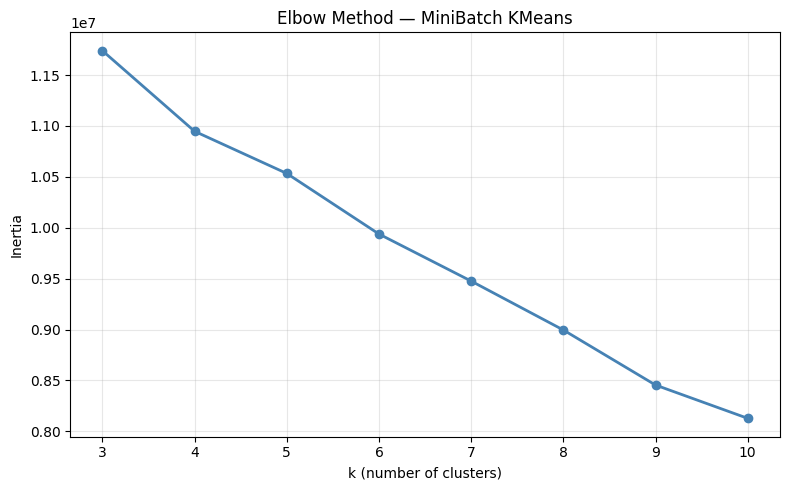

k= 3  inertia=11,739,344
k= 4  inertia=10,947,523
k= 5  inertia=10,533,480
k= 6  inertia=9,938,217
k= 7  inertia=9,475,869
k= 8  inertia=8,995,252
k= 9  inertia=8,454,511
k=10  inertia=8,127,440


In [21]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Need X_scaled for the elbow — build it here without overwriting anything.
numeric_cols = ["log_spend_random_factor", "dist_hhi", "top1_share_pct", "mfr_hhi",
                "risk_high_flag", "total_hdd", "total_cdd", "temp_volatility"]
X_probe = pd.concat([seg_df[numeric_cols], cat_onehot, dist_onehot, entity_onehot, room_onehot], axis=1)
X_probe = X_probe.astype({c: int for c in X_probe.select_dtypes(include="bool").columns}).fillna(0)
X_probe_scaled = StandardScaler().fit_transform(X_probe)

inertias = []
k_values = range(3, 11)
for k in k_values:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=10000, n_init=10)
    km.fit(X_probe_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o", linewidth=2, color="steelblue")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.title("Elbow Method — MiniBatch KMeans")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for k, i in zip(k_values, inertias):
    print(f"k={k:2d}  inertia={i:,.0f}")


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans

numeric_cols = ["log_spend_random_factor", "dist_hhi", "top1_share_pct", "mfr_hhi",
                "risk_high_flag", "total_hdd", "total_cdd", "temp_volatility"]

X = pd.concat([seg_df[numeric_cols], cat_onehot, dist_onehot, entity_onehot, room_onehot], axis=1)
X = X.astype({c: int for c in X.select_dtypes(include="bool").columns}).fillna(0)

X_scaled = StandardScaler().fit_transform(X)

kmeans = MiniBatchKMeans(n_clusters=6, random_state=42, batch_size=10000, n_init=10)
seg_df["cluster"] = kmeans.fit_predict(X_scaled)

print("X shape:", X.shape)
print("\nCluster sizes:")
print(seg_df["cluster"].value_counts().sort_index())


X shape: (516010, 27)

Cluster sizes:
cluster
0     14820
1     98128
2     69681
3     53010
4     66222
5    214149
Name: count, dtype: int64


In [17]:
def mode_or_none(s):
    m = s.mode()
    return m.iloc[0] if len(m) else None

profile = (
    seg_df.groupby("cluster", observed=True)
    .agg(
        n_rows           = ("cluster", "size"),
        mean_spend       = ("spend_random_factor", "mean"),
        mean_rooms       = ("number_of_rooms", "mean"),
        mean_dist_hhi    = ("dist_hhi", "mean"),
        mean_top1_share  = ("top1_share_pct", "mean"),
        mean_total_hdd   = ("total_hdd", "mean"),
        mean_total_cdd   = ("total_cdd", "mean"),
        pct_high_risk    = ("risk_high_flag", "mean"),
        top_category     = ("category_level_1", mode_or_none),
        top_distributor  = ("distributor_group", mode_or_none),
        top_entity       = ("business_entity_type", mode_or_none),
        top_room_band    = ("room_band", mode_or_none),
        top_state        = ("state", mode_or_none),
    )
    .round(2)
    .sort_values("mean_spend", ascending=False)
)

profile["pct_high_risk"] = (profile["pct_high_risk"] * 100).round(1)
profile


,n_rows,mean_spend,mean_rooms,mean_dist_hhi,mean_top1_share,mean_total_hdd,mean_total_cdd,pct_high_risk,top_category,top_distributor,top_entity,top_room_band,top_state
cluster,,,,,,,,,,,,,
0,14820,274.24,99.13,3217.27,54.62,3917.77,1608.20,84.0,BEVERAGE,DIRECT BEVERAGE,GPO,0_non_hospitality,TX
1,98128,237.90,0.0,3207.48,54.48,4093.12,1593.66,84.0,FOOD,MASTER DISTRIBUTOR,MANAGED SERVICES,0_non_hospitality,TX
2,69681,173.71,159.14,3325.41,55.83,3515.37,1724.14,94.0,MAINTENANCE AND ENGINEERING,ENGINEERING MRO,GPO,101_300,CA
5,214149,121.34,134.23,3460.87,57.12,3776.34,1653.48,100.0,FOOD,MASTER DISTRIBUTOR,GPO,0_non_hospitality,CA
3,53010,116.94,144.14,2199.14,43.85,5175.56,886.33,0.0,FOOD,MASTER DISTRIBUTOR,GPO,101_300,NY
4,66222,52.50,63.9,3621.37,58.48,4080.81,1480.19,100.0,FOOD,MASTER DISTRIBUTOR,GPO,1_100,CA


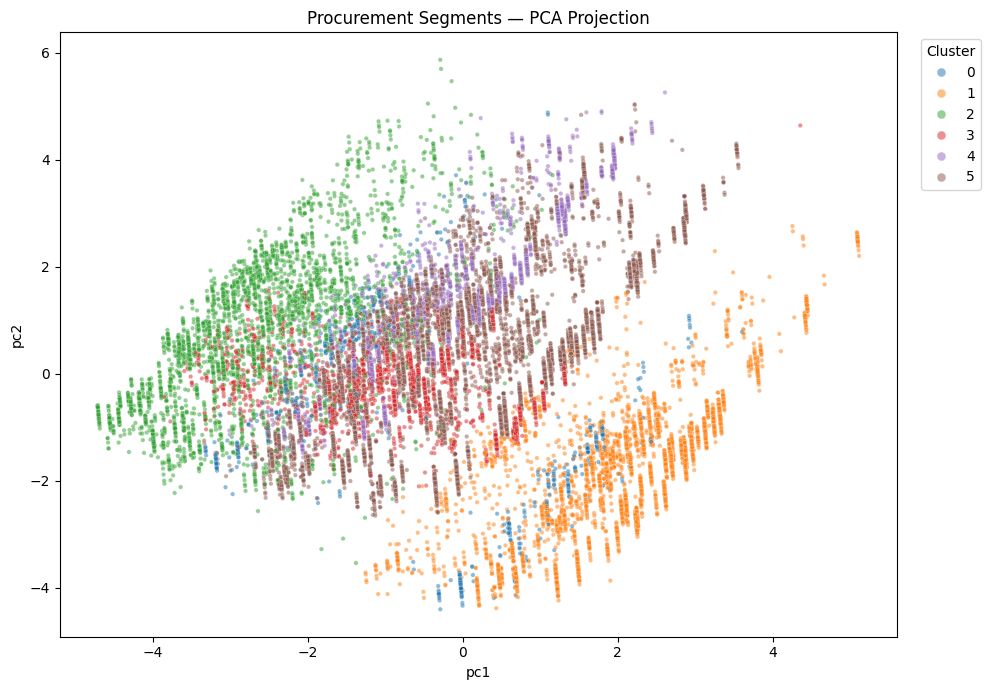

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
plot_df = pd.DataFrame({"pc1": X_pca[:,0], "pc2": X_pca[:,1], "cluster": seg_df["cluster"].values})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df.sample(25000, random_state=42),
                x="pc1", y="pc2", hue="cluster", palette="tab10", alpha=0.5, s=10)
plt.title("Procurement Segments — PCA Projection")
plt.legend(markerscale=2, title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Phase 7 — Cluster Summary

Six procurement segments surfaced from the clustering. Every cluster is differentiated on multiple axes — spend intensity, concentration risk, category specialty, distributor channel, entity type, room scale, and weather exposure.

### Segment profiles

**Cluster 0 — Specialty Beverage Procurement** (14.8K rows, mean spend $274)
The only segment where `BEVERAGE` is the top category and `DIRECT BEVERAGE` is the top distributor. Highest average transaction size of any cluster. Specialty-channel buyers operating outside the MASTER DISTRIBUTOR flow. Dominant state: TX.

**Cluster 1 — Managed Services Food Institutions** (98.1K rows, mean spend $238)
The only segment dominated by `MANAGED SERVICES` entity type. Non-hospitality, high transaction value, top state TX. Represents large institutional food service accounts (hospitals, corporate campuses, universities).

**Cluster 2 — Facility & Engineering Operations** (69.7K rows, mean spend $174)
The only segment where `MAINTENANCE AND ENGINEERING` is the top category and `ENGINEERING MRO` is the top distributor. Mid-size hospitality (101–300 rooms) running active facility-maintenance programs. 94% of rows sit in HIGH-risk states; top state CA.

**Cluster 3 — Northeast Moderate-Risk Food Buyers** (53.0K rows, mean spend $117)
The only segment with 0% HIGH-risk rows (lowest mean `dist_hhi` at 2,199). Highest average HDD (5,176) and lowest CDD (886) — cold, northeastern states. Top state NY. These are the customers with genuine supplier-channel diversity.

**Cluster 4 — Small-Property Low-Spend Buyers** (66.2K rows, mean spend $52)
Lowest transaction value in the dataset. Dominant room band is 1–100 rooms — small hotels and restaurants. 100% HIGH-risk; GPO entity; FOOD through MASTER DISTRIBUTOR. The long-tail accounts.

**Cluster 5 — GPO Mass-Market Food Backbone** (214.1K rows, mean spend $121)
The largest cluster — roughly 41% of the full sample. 100% HIGH-risk concentration. The core of Aramark's business: GPO, non-hospitality, FOOD through MASTER DISTRIBUTOR at moderate transaction sizes.
